IMPORT THE DATASET

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Traffic Analysis_Final.csv")

print("Shape:", df.shape)

Shape: (5000, 14)


Perform Exploratory Data Analysis (EDA)

In [ ]:
print(df.info())
print(df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               5000 non-null   object 
 1   Latitude                5000 non-null   float64
 2   Longitude               5000 non-null   float64
 3   Vehicle_Count           5000 non-null   int64  
 4   Traffic_Speed_kmh       5000 non-null   float64
 5   Road_Occupancy_%        5000 non-null   float64
 6   Traffic_Light_State     5000 non-null   object 
 7   Weather_Condition       5000 non-null   object 
 8   Accident_Report         5000 non-null   int64  
 9   Ride_Sharing_Demand     5000 non-null   int64  
 10  Parking_Availability    5000 non-null   int64  
 11  Emission_Levels_g_km    5000 non-null   float64
 12  Energy_Consumption_L_h  5000 non-null   float64
 13  Traffic_Condition       5000 non-null   object 
dtypes: float64(6), int64(4), object(4)
memor

In [ ]:
missing = df.isnull().sum()

missing[missing > 0]

,0


In [ ]:
missing_percent = (df.isnull().sum()/len(df))*100

missing_percent[missing_percent>0]

,0


In [ ]:
print("Duplicate Rows:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicate Rows: 0


In [ ]:
df.describe()

,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Accident_Report,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,40.749645,-73.847433,153.921200,42.111096,54.748397,0.096000,50.487800,24.613000,272.174927,17.343243
std,0.086123,0.086204,83.523342,21.707720,26.145238,0.294621,28.484426,14.532511,130.086372,7.208277
min,40.600016,-73.999987,10.000000,5.002789,10.005031,0.000000,1.000000,0.000000,50.136855,5.003787
25%,40.675403,-73.920281,80.000000,23.195752,32.089653,0.000000,26.000000,12.000000,160.564433,11.098761
50%,40.748875,-73.846058,156.000000,42.191599,54.657297,0.000000,50.000000,24.000000,272.045513,17.153791
75%,40.824735,-73.771685,226.000000,60.751760,77.581720,0.000000,75.000000,37.000000,382.242055,23.516595
max,40.899972,-73.700159,299.000000,79.997556,99.999729,1.000000,99.000000,49.000000,499.922663,29.995416


In [ ]:
df["Timestamp"] = pd.to_datetime(
    df["Timestamp"],
    format="%d-%m-%Y %H:%M"
)

df.head()

,Timestamp,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h,Traffic_Condition
0,2024-03-01 00:00:00,40.842275,-73.703149,205,49.893435,82.652780,Yellow,Clear,0,2,45,450.760055,19.574337,High
1,2024-03-01 00:05:00,40.831119,-73.987354,202,22.383965,45.829298,Green,Clear,0,16,1,321.800341,5.385554,High
2,2024-03-01 00:10:00,40.819549,-73.732462,252,46.889699,82.772465,Green,Rain,0,16,49,231.152655,10.277477,High
3,2024-03-01 00:15:00,40.725849,-73.980134,37,5.730536,37.695567,Red,Fog,0,66,10,410.384292,29.243279,High
4,2024-03-01 00:20:00,40.813265,-73.961631,64,61.348034,22.313358,Red,Snow,0,3,5,364.466342,16.801459,Low


In [ ]:
df["Date"] = df["Timestamp"].dt.date
df["Hour"] = df["Timestamp"].dt.hour
df["Day"] = df["Timestamp"].dt.day_name()

In [ ]:
missing = df.isnull().sum()

missing[missing > 0]

,0


In [ ]:
missing_percent = (df.isnull().sum()/len(df))*100

missing_percent[missing_percent>0]

,0


In [ ]:
print("Duplicate Rows:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicate Rows: 0


In [ ]:
df.describe()

,Timestamp,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Accident_Report,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h,Hour
count,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2024-03-09 16:17:30,40.749645,-73.847433,153.921200,42.111096,54.748397,0.096000,50.487800,24.613000,272.174927,17.343243,11.340800
min,2024-03-01 00:00:00,40.600016,-73.999987,10.000000,5.002789,10.005031,0.000000,1.000000,0.000000,50.136855,5.003787,0.000000
25%,2024-03-05 08:08:45,40.675403,-73.920281,80.000000,23.195752,32.089653,0.000000,26.000000,12.000000,160.564433,11.098761,5.000000
50%,2024-03-09 16:17:30,40.748875,-73.846058,156.000000,42.191599,54.657297,0.000000,50.000000,24.000000,272.045513,17.153791,11.000000
75%,2024-03-14 00:26:15,40.824735,-73.771685,226.000000,60.751760,77.581720,0.000000,75.000000,37.000000,382.242055,23.516595,17.000000
max,2024-03-18 08:35:00,40.899972,-73.700159,299.000000,79.997556,99.999729,1.000000,99.000000,49.000000,499.922663,29.995416,23.000000
std,NaN,0.086123,0.086204,83.523342,21.707720,26.145238,0.294621,28.484426,14.532511,130.086372,7.208277,6.946474


Analyze Dataset Structure, Features, and Distributions

In [ ]:
print(df.columns)

Index(['Timestamp', 'Latitude', 'Longitude', 'Vehicle_Count',
       'Traffic_Speed_kmh', 'Road_Occupancy_%', 'Traffic_Light_State',
       'Weather_Condition', 'Accident_Report', 'Ride_Sharing_Demand',
       'Parking_Availability', 'Emission_Levels_g_km',
       'Energy_Consumption_L_h', 'Traffic_Condition', 'Date', 'Hour', 'Day'],
      dtype='object')


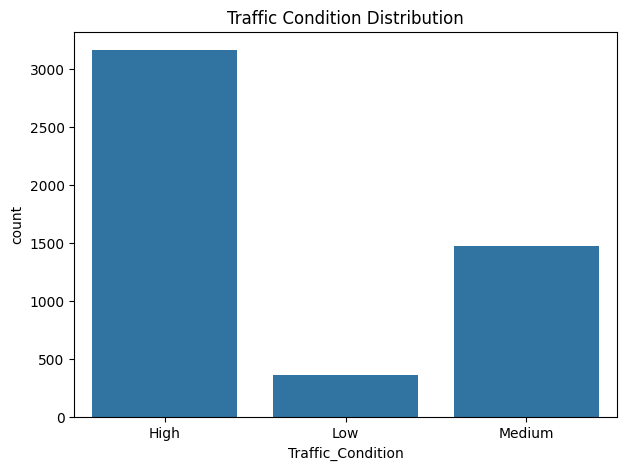

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="Traffic_Condition",
    data=df
)

plt.title("Traffic Condition Distribution")

plt.show()

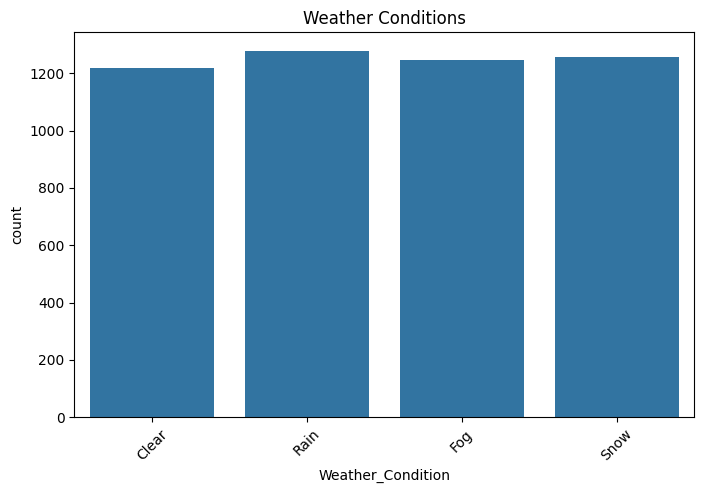

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Weather_Condition",
    data=df
)

plt.title("Weather Conditions")

plt.xticks(rotation=45)

plt.show()

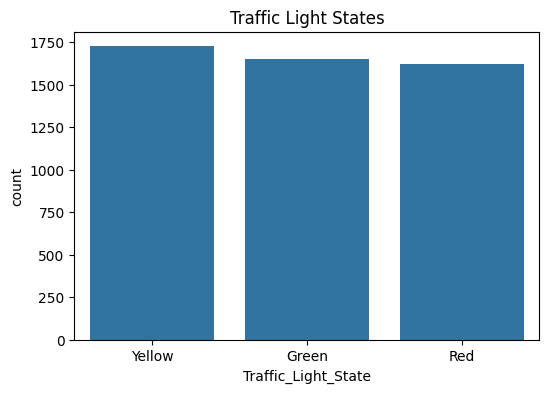

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Traffic_Light_State",
    data=df
)

plt.title("Traffic Light States")

plt.show()

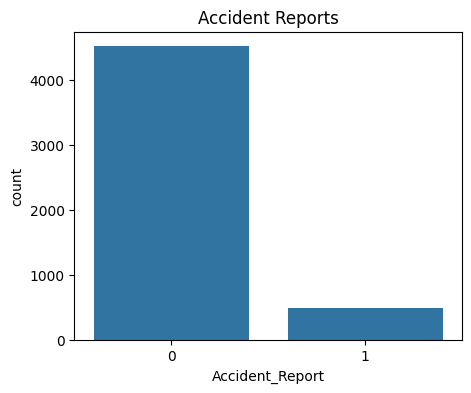

In [ ]:
plt.figure(figsize=(5,4))

sns.countplot(
    x="Accident_Report",
    data=df
)

plt.title("Accident Reports")

plt.show()

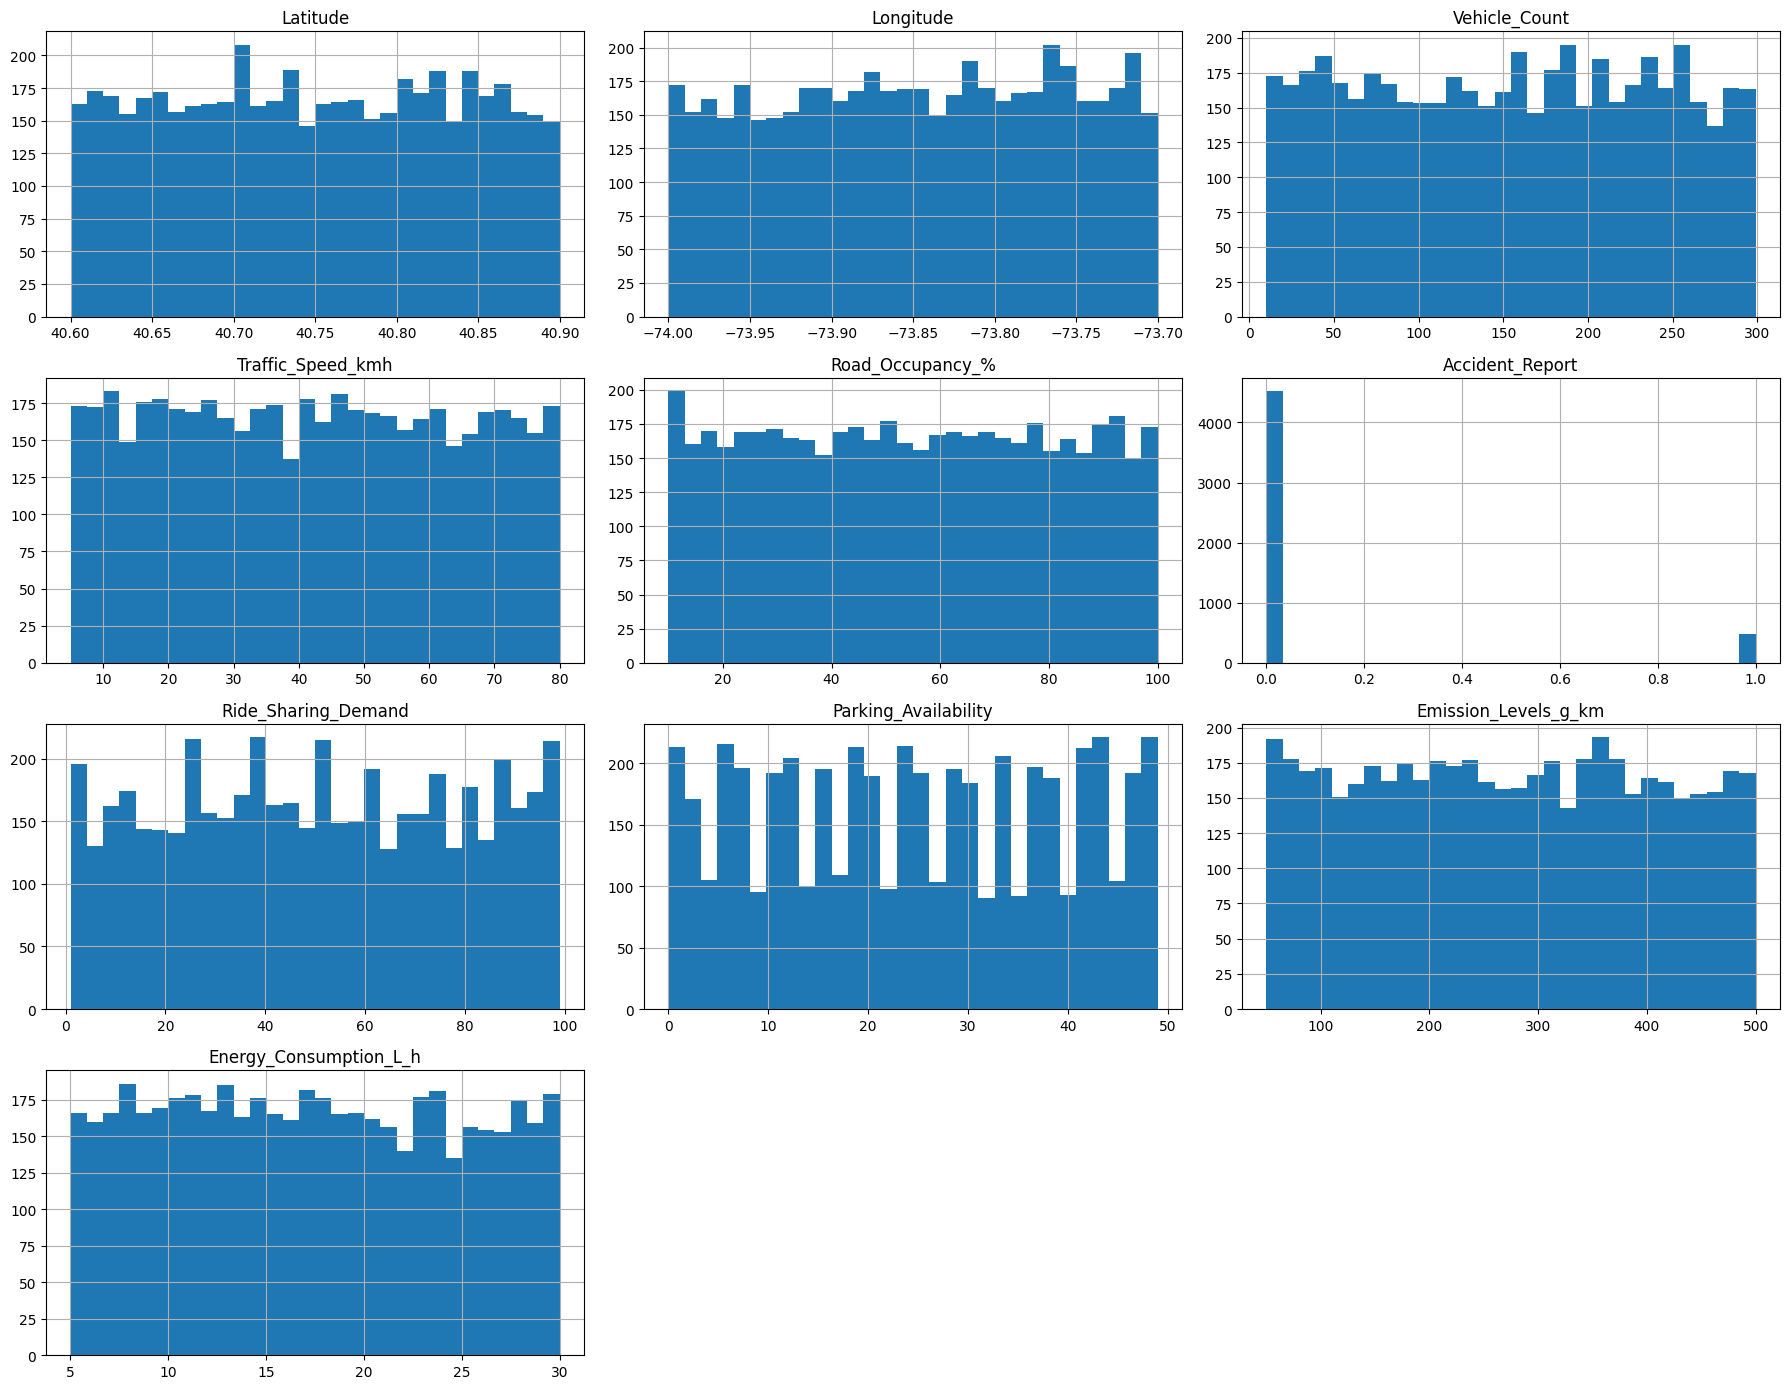

In [ ]:
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns

df[numeric_cols].hist(figsize=(18,14), bins=30)

plt.tight_layout()

plt.show()

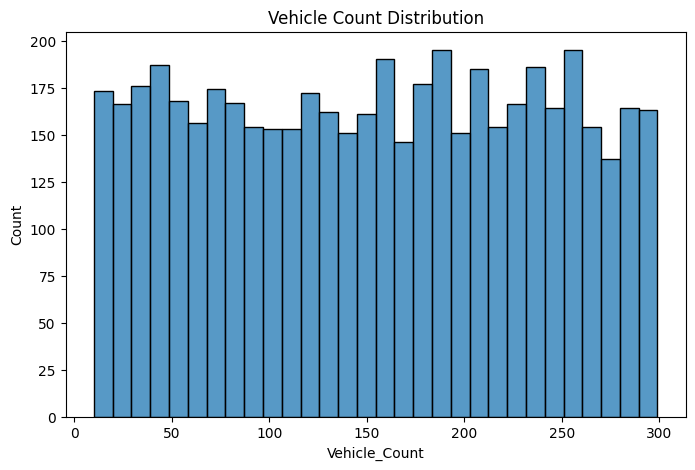

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Vehicle_Count"],
    bins=30
)

plt.title("Vehicle Count Distribution")

plt.show()

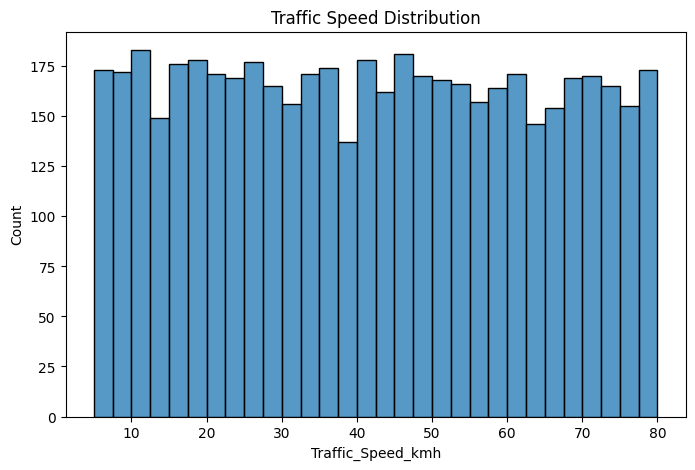

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Traffic_Speed_kmh"],
    bins=30
)

plt.title("Traffic Speed Distribution")

plt.show()

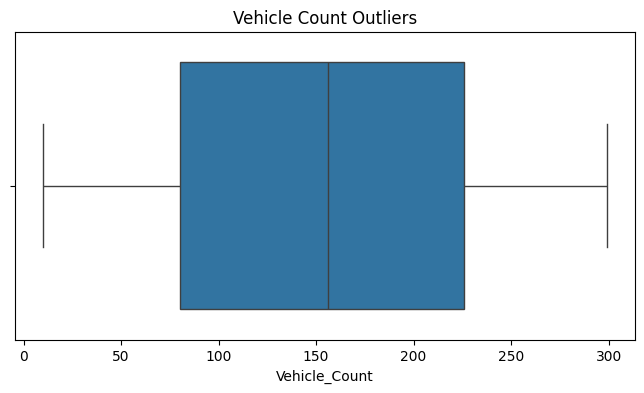

In [ ]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df["Vehicle_Count"]
)

plt.title("Vehicle Count Outliers")

plt.show()

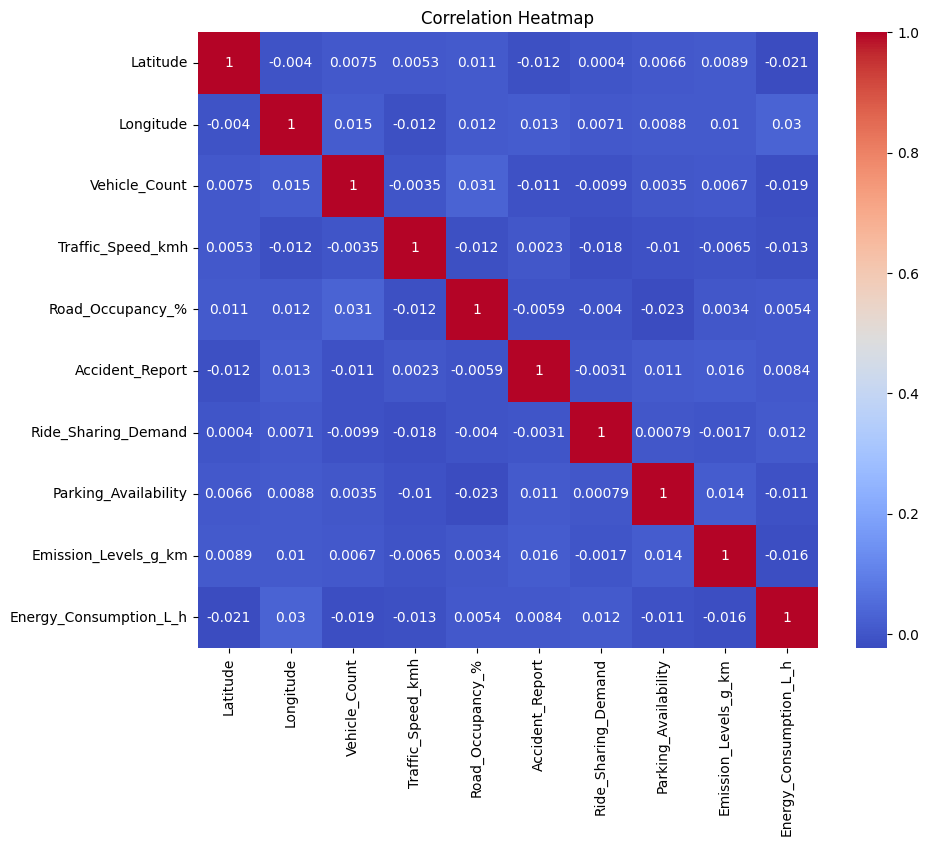

In [ ]:
plt.figure(figsize=(10,8))

corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

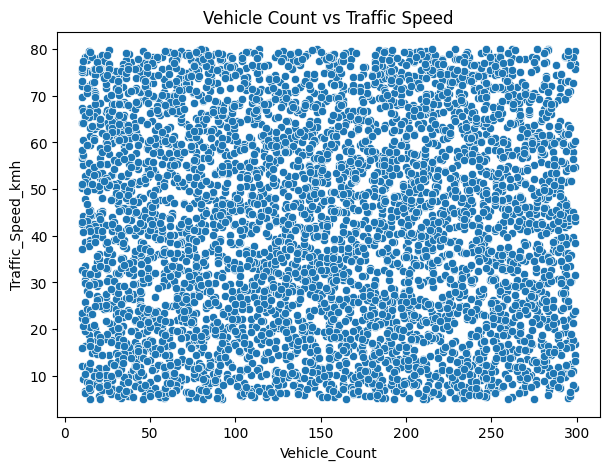

In [ ]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x="Vehicle_Count",
    y="Traffic_Speed_kmh",
    data=df
)

plt.title("Vehicle Count vs Traffic Speed")

plt.show()

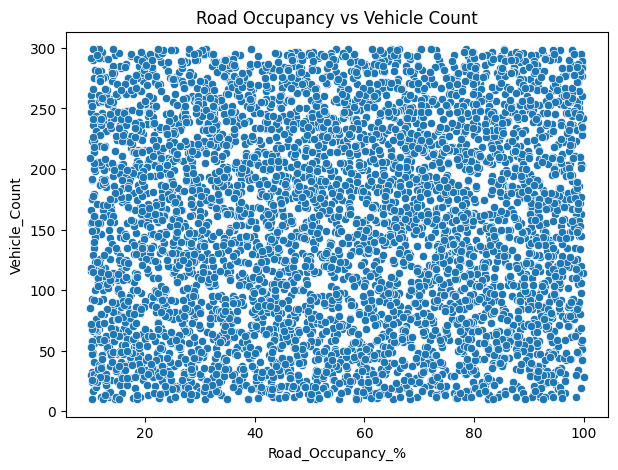

In [ ]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x="Road_Occupancy_%",
    y="Vehicle_Count",
    data=df
)

plt.title("Road Occupancy vs Vehicle Count")

plt.show()

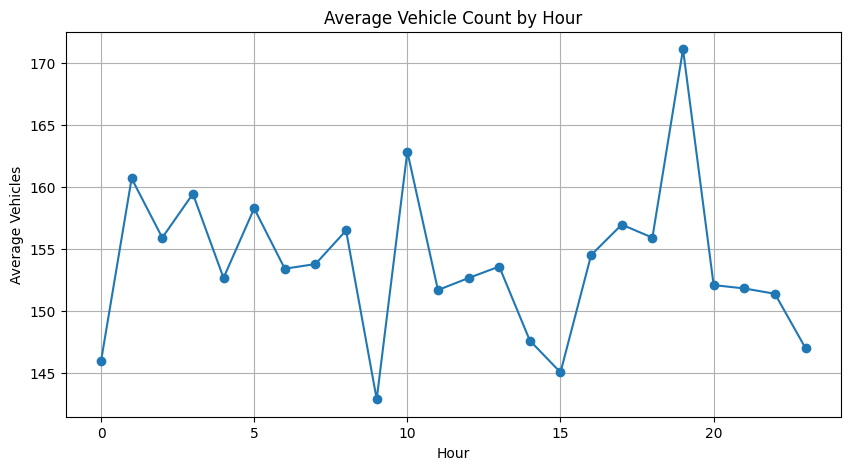

In [ ]:
plt.figure(figsize=(10,5))

df.groupby("Hour")["Vehicle_Count"].mean().plot(marker="o")

plt.title("Average Vehicle Count by Hour")

plt.xlabel("Hour")

plt.ylabel("Average Vehicles")

plt.grid(True)

plt.show()

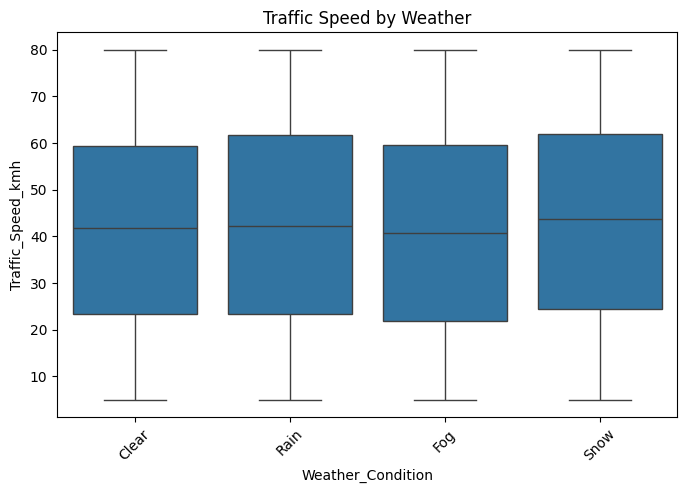

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Weather_Condition",
    y="Traffic_Speed_kmh",
    data=df
)

plt.xticks(rotation=45)

plt.title("Traffic Speed by Weather")

plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv("Traffic Analysis_Final.csv")

# -------------------------------
# Data Preprocessing
# -------------------------------

# Convert Timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%d-%m-%Y %H:%M')

# Extract useful time-based features
df['Year'] = df['Timestamp'].dt.year
df['Month'] = df['Timestamp'].dt.month
df['Day'] = df['Timestamp'].dt.day
df['Hour'] = df['Timestamp'].dt.hour

# Drop original Timestamp column
df.drop('Timestamp', axis=1, inplace=True)

# One-hot encode categorical variables
df = pd.get_dummies(
    df,
    columns=[
        'Traffic_Light_State',
        'Weather_Condition'
    ],
    drop_first=True
)

# -------------------------------
# Define Features and Target
# -------------------------------

X = df.drop('Traffic_Condition', axis=1)
y = df['Traffic_Condition']

# -------------------------------
# Train (70%) | Validation (15%) | Test (15%)
# -------------------------------

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training Set :", X_train.shape, y_train.shape)
print("Validation Set:", X_val.shape, y_val.shape)
print("Testing Set  :", X_test.shape, y_test.shape)

Training Set : (3500, 19) (3500,)
Validation Set: (750, 19) (750,)
Testing Set  : (750, 19) (750,)


                       Feature  Importance
2                Vehicle_Count    0.335450
4             Road_Occupancy_%    0.231957
3            Traffic_Speed_kmh    0.214642
5              Accident_Report    0.078290
1                    Longitude    0.018754
9       Energy_Consumption_L_h    0.018038
0                     Latitude    0.017523
8         Emission_Levels_g_km    0.016861
7         Parking_Availability    0.015915
6          Ride_Sharing_Demand    0.015711
13                        Hour    0.013476
12                         Day    0.011562
18      Weather_Condition_Snow    0.002585
15  Traffic_Light_State_Yellow    0.002573
17      Weather_Condition_Rain    0.002389
14     Traffic_Light_State_Red    0.002167
16       Weather_Condition_Fog    0.002107
10                        Year    0.000000
11                       Month    0.000000


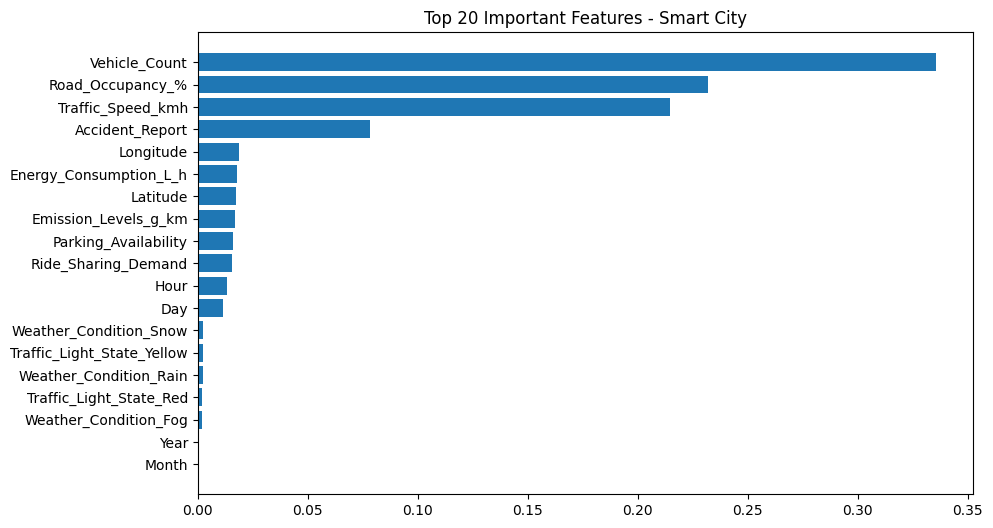

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(20))

plt.figure(figsize=(10,6))
plt.barh(
    importance['Feature'][:20],
    importance['Importance'][:20]
)
plt.gca().invert_yaxis()
plt.title("Top 20 Important Features - Smart City")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Smart City Dataset Performance")
print("------------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall :", recall)
print("F1 Score :", f1)

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

Smart City Dataset Performance
------------------------------
Accuracy : 0.9986666666666667
Precision: 0.9986726726726728
Recall : 0.9986666666666667
F1 Score : 0.9986619410279669

Classification Report

              precision    recall  f1-score   support

        High       1.00      1.00      1.00       475
         Low       1.00      0.98      0.99        54
      Medium       1.00      1.00      1.00       221

    accuracy                           1.00       750
   macro avg       1.00      0.99      1.00       750
weighted avg       1.00      1.00      1.00       750

